# Retrieval — Blackbody vs. Atmospheric Model
Fits the binned emission spectrum using two models:
1. **Blackbody**: Planck fit with scipy (free params: $T_p$, $(R_p/R_*)^2$)
2. **Atmospheric**: TauREx `EmissionModel` with molecular absorbers and nested-sampling retrieval

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os
import xarray as xr

import astropy.constants as const
import scipy.optimize as opt
import scipy.constants as sc

import taurex
from taurex.cache import OpacityCache, CIACache
OpacityCache().clear_cache()
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature    import Isothermal, TemperatureFile
from taurex.chemistry      import TaurexChemistry, ConstantGas
from taurex.planet         import Planet
from taurex.stellar        import BlackbodyStar
from taurex.model          import EmissionModel
from taurex.pressure       import SimplePressureProfile
from taurex.contributions  import AbsorptionContribution, CIAContribution, RayleighContribution
from taurex.binning        import FluxBinner
from taurex.data.spectrum  import BaseSpectrum
from taurex.output.hdf5    import HDF5Output
from taurex.taurexdefs     import OutputSize

print('TauREx version:', taurex.__version__)

Numba not installed, using numpy instead
TauREx version: 3.3.1


## 1 — Parameters & data loading

In [2]:
planet_names        = ['HD3167','K2141','LHS1478','TOI431','TOI500','TOI561','TOI1416','TOI1807']
planet_masses       = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44]           # M_earth
planet_distances    = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012]   # AU
planet_period       = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55]            # days
planet_radius       = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496]   # R_earth
planet_transit_hr   = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98]            # hours
planet_transit      = [n * 3600 for n in planet_transit_hr]                        # seconds
planet_impact       = [0.181, -0.01, 0.717, 0.34, 0.53, 0.14, 0.39, 0.489]

star_temperature    = [5261.0, 4570.0, 3381.0, 4850.0, 4440.0, 5342.0, 4884.0, 4914.0]  # K
star_radius         = [0.872, 0.681, 0.246, 0.731, 0.678, 0.856, 0.793, 0.746]           # R_sun
star_metallicity    = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04]                  # [Fe/H]
star_distance       = [47.28, 61.87, 18.22, 32.6, 47.39, 85.8, 55.01, 42.58]             # pc

# ── Active target ─────────────────────────────────────────────────────────────
planet_name = 'HD3167'
sim_name    = 'H10_IW4_00001'

idx        = planet_names.index(planet_name)
mass_jup   = planet_masses[idx] / 317.8
radius_jup = planet_radius[idx] * (const.R_earth.value / const.R_jup.value)
a_AU       = planet_distances[idx]

print(f'Target : {planet_name}b  ({sim_name})')
print(f'  Rp = {planet_radius[idx]:.3f} R_earth = {radius_jup:.4f} R_jup')
print(f'  Mp = {planet_masses[idx]:.2f} M_earth')
print(f'  T* = {star_temperature[idx]:.0f} K,  R* = {star_radius[idx]:.3f} R_sun')

Target : HD3167b  (H10_IW4_00001)
  Rp = 1.627 R_earth = 0.1452 R_jup
  Mp = 4.73 M_earth
  T* = 5261 K,  R* = 0.872 R_sun


Loaded 14 spectral bins
Wavelength : 0.625 – 6.612 µm
Flux       : 12.7 – 67.2 ppm


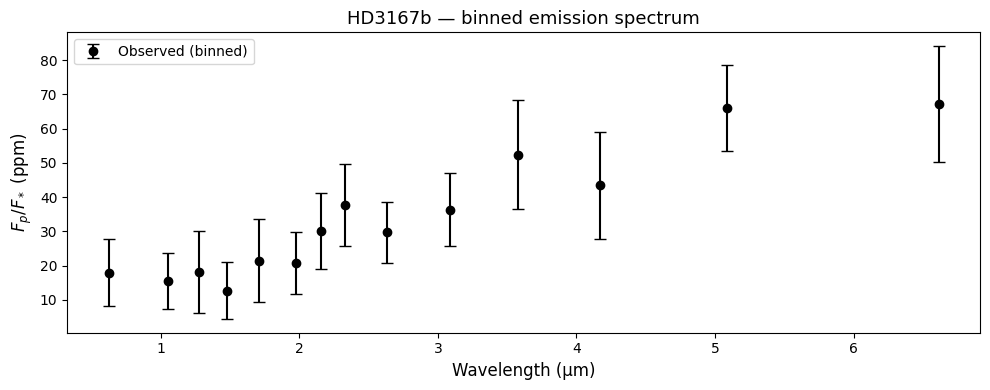

In [3]:
spec_path = f'PLANETS/{planet_name}/{sim_name}_binned_spectrum.csv'
df_spec   = pd.read_csv(spec_path)

wl_obs   = df_spec['Wavelength (µm)'].values
flux_obs = df_spec['Flux Ratio'].values
err_obs  = df_spec['Error'].values

print(f'Loaded {len(wl_obs)} spectral bins')
print(f'Wavelength : {wl_obs.min():.3f} – {wl_obs.max():.3f} µm')
print(f'Flux       : {flux_obs.min()*1e6:.1f} – {flux_obs.max()*1e6:.1f} ppm')

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(wl_obs, flux_obs * 1e6, yerr=err_obs * 1e6,
            fmt='o', color='black', capsize=4, label='Observed (binned)')
ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_ylabel(r'$F_p/F_*$ (ppm)', fontsize=12)
ax.set_title(f'{planet_name}b — binned emission spectrum', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 2 — Blackbody fit (scipy)
Model: $F_p/F_* = k \cdot B(T_p,\lambda) / B(T_*,\lambda)$  
where $k = (R_p/R_*)^2$ and $B$ is the Planck function.

Best-fit T_p  = 2362.9 ± 227.9 K
Best-fit k    = 0.00018 ± 0.00004  →  Rp/Rs = 0.0135
(geometric Rp/Rs = 0.0171)
Reduced χ² = 0.59


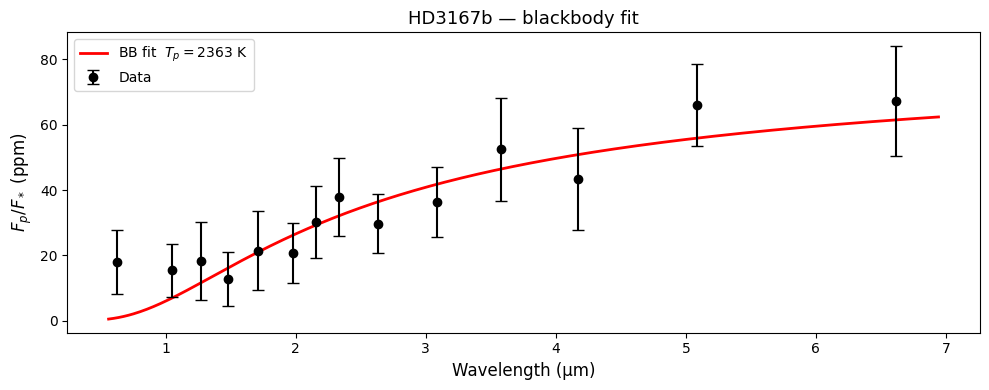

In [ ]:
def planck(wl_um, T):
    """Planck function [W m^-2 um^-1 sr^-1]."""
    wl_m = wl_um * 1e-6
    return (2 * sc.h * sc.c**2 / wl_m**5) / (np.exp(sc.h * sc.c / (wl_m * sc.k * T)) - 1.0)

def bb_fpfs(wl_um, T_planet, k_rp_rs2):
    return k_rp_rs2 * planck(wl_um, T_planet) / planck(wl_um, star_temperature[idx])

# Geometric (Rp/Rs)^2 as initial guess
rp_rs_sq_0 = (planet_radius[idx] * const.R_earth.value /
              (star_radius[idx]  * const.R_sun.value)) ** 2

popt, pcov = opt.curve_fit(
    bb_fpfs, wl_obs, flux_obs,
    p0     = [2000.0, rp_rs_sq_0],
    sigma  = err_obs,
    bounds = ([500,  0.5 * rp_rs_sq_0], [5000, 2.0 * rp_rs_sq_0]),
)
perr   = np.sqrt(np.diag(pcov))
T_bb   = popt[0];  T_bb_err   = perr[0]
k_bb   = popt[1];  k_bb_err   = perr[1]

residuals  = (flux_obs - bb_fpfs(wl_obs, *popt)) / err_obs
chi2_red   = np.sum(residuals**2) / (len(wl_obs) - 2)

print(f'Best-fit T_p  = {T_bb:.1f} ± {T_bb_err:.1f} K')
print(f'Best-fit k    = {k_bb:.5f} ± {k_bb_err:.5f}  →  Rp/Rs = {np.sqrt(k_bb):.4f}')
print(f'(geometric Rp/Rs = {np.sqrt(rp_rs_sq_0):.4f})')
print(f'Reduced χ² = {chi2_red:.2f}')

wl_fine = np.linspace(wl_obs.min() * 0.9, wl_obs.max() * 1.05, 500)
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(wl_obs, flux_obs * 1e6, err_obs * 1e6,
            fmt='ko', capsize=4, zorder=5, label='Data')
ax.plot(wl_fine, bb_fpfs(wl_fine, T_bb, k_bb) * 1e6, 'r-', lw=2,
        label=f'BB fit  $T_p={T_bb:.0f}$ K')
ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_ylabel(r'$F_p/F_*$ (ppm)', fontsize=12)
ax.set_title(f'{planet_name}b — blackbody fit', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

#save blackbody fit as csv
df_bb = pd.DataFrame({
    'Wavelength (µm)': wl_fine,
    'Flux Ratio': bb_fpfs(wl_fine, T_bb, k_bb),
})
df_bb.to_csv(f'PLANETS/{planet_name}/{sim_name}_blackbody_fit.csv', index=False)

## 3 — TauREx forward model check
Build the full atmospheric `EmissionModel` with simulation chemistry and verify
that the forward pass reproduces the expected spectrum before running any retrieval.

In [5]:
class ArraySpectrum(BaseSpectrum):
    """
    Thin BaseSpectrum wrapper around numpy arrays.
    Bin edges are computed from midpoints between adjacent wavelength samples.
    """
    def __init__(self, wl_um, flux, error):
        super().__init__('ArraySpectrum')
        order = np.argsort(wl_um)           # ascending λ
        wl    = wl_um[order]

        # bin edges in µm (n+1 values)
        edges = np.concatenate([
            [wl[0]  - (wl[1]  - wl[0])  / 2],
            (wl[:-1] + wl[1:]) / 2,
            [wl[-1] + (wl[-1] - wl[-2]) / 2],
        ])

        # wavenumber grids (cm^-1), ascending order
        wn       = (10000.0 / wl)[::-1]
        wn_edges = (10000.0 / edges)[::-1]

        self._wlgrid     = wl[::-1]
        self._wngrid     = wn
        self._spectrum   = flux[order][::-1]
        self._error      = error[order][::-1]
        self._bin_widths = np.diff(wn_edges)
        self._bin_edges  = wn_edges

    @property
    def spectrum(self):       return self._spectrum
    @property
    def errorBar(self):       return self._error
    @property
    def wavelengthGrid(self): return self._wlgrid
    @property
    def wavenumberGrid(self): return self._wngrid
    @property
    def binWidths(self):      return self._bin_widths
    @property
    def binEdges(self):       return self._bin_edges


observation = ArraySpectrum(wl_obs, flux_obs, err_obs)
print('Wavenumber grid (cm⁻¹):', observation.wavenumberGrid.round(1))

Wavenumber grid (cm⁻¹): [ 1512.5  1966.1  2398.8  2793.1  3241.2  3800.6  4286.   4641.1  5055.6
  5853.1  6767.7  7843.7  9495.  16000. ]


In [6]:
# ── Shared Planet / Star / Pressure objects ───────────────────────────────────
pl = Planet(
    planet_mass     = mass_jup,
    planet_radius   = radius_jup,
    planet_sma      = a_AU,
    planet_distance = star_distance[idx],
    impact_param    = planet_impact[idx],
    orbital_period  = planet_period[idx],
    transit_time    = planet_transit[idx],
)

# BlackbodyStar: fast and sufficient for retrieval
# (swap for PhoenixStar(... phoenix_path='Phoenix/') if needed)
st = BlackbodyStar(
    temperature = star_temperature[idx],
    radius      = star_radius[idx],
)

pres = SimplePressureProfile(nlayers=50, atm_min_pressure=1e-4, atm_max_pressure=1e6)

CIA_PAIRS = ['CO2-CO2', 'CO2-H2', 'CO2-H2O', 'CO2-CH4',
             'H2-H2', 'N2-N2', 'N2-H2', 'N2-H2O', 'N2-CH4',
             'O2-CO2', 'O2-N2', 'O2-O2']

print(f'Planet: Rp={pl.fullRadius/const.R_earth.value:.3f} R_earth')

Planet: Rp=1.627 R_earth


In [7]:
# ── Load simulation chemistry from the .nc atmosphere file ───────────────────
sim_folder = f'PLANETS/{planet_name}/{sim_name}'
atm_file   = next(os.path.join(sim_folder, f)
                  for f in os.listdir(sim_folder) if f.endswith('atm.nc'))

ds         = xr.open_dataset(atm_file)
gases_list = [m.decode().strip() if isinstance(m, bytes) else m.strip()
              for m in ds['gases'].values]
vmr        = np.array(ds['x_gas'])     # shape: (nlayers, nspecies)

def get_vmr(mol):
    return float(vmr[:, gases_list.index(mol)][0]) if mol in gases_list else 0.0

ALL_MOLS   = ['H2O','CO2','CH4','CO','NH3','SO2','O2','H2','H2S','N2','S2']
mol_vmrs   = {m: get_vmr(m) for m in ALL_MOLS}

total = sum(mol_vmrs.values())
if total > 1:
    mol_vmrs = {k: v / total for k, v in mol_vmrs.items()}

print('Simulation VMRs (top layer):')
for mol, x in sorted(mol_vmrs.items(), key=lambda kv: -kv[1]):
    if x > 1e-12:
        print(f'  {mol:6s}: {x:.3e}')

Simulation VMRs (top layer):
  SO2   : 7.343e-01
  H2O   : 1.878e-01
  O2    : 6.482e-02
  S2    : 8.109e-03
  H2    : 4.365e-03
  H2S   : 3.288e-04
  CO2   : 2.176e-04
  CO    : 3.457e-05


In [8]:
# ── Build TauREx forward model with simulation TP + chemistry ─────────────────
tp_file = f'PLANETS/{planet_name}/{sim_name}_TP.csv'
tp_data = pd.read_csv(tp_file)
surf_p  = float(tp_data['Pressure (Pa)'].values[0])
top_p   = float(tp_data['Pressure (Pa)'].values[-1])

tp_sim = TemperatureFile(
    tp_file, skiprows=1,
    temp_col=2, press_col=0,         # col 2 = substellar (dayside) T
    temp_units='K', press_units='Pa',
    delimiter=','
)

pres_sim = SimplePressureProfile(nlayers=100,
                                 atm_min_pressure=top_p,
                                 atm_max_pressure=surf_p)

chem_sim = TaurexChemistry(fill_gases=['N2'])
for mol, xmol in mol_vmrs.items():
    if mol != 'N2' and xmol > 1e-12:
        try:
            chem_sim.addGas(ConstantGas(molecule_name=mol, mix_ratio=xmol))
        except Exception:
            pass   # skip molecules not in the xsec library

em_fwd = EmissionModel(planet=pl, temperature_profile=tp_sim,
                       chemistry=chem_sim, pressure_profile=pres_sim, star=st)
em_fwd.add_contribution(AbsorptionContribution())
em_fwd.add_contribution(CIAContribution(cia_pairs=CIA_PAIRS))
em_fwd.add_contribution(RayleighContribution())
em_fwd.build()

print('Running forward model...')
wn_fwd, fpfs_fwd, _, _ = em_fwd.model()

binner_fwd = FluxBinner(wngrid=observation.wavenumberGrid, wngrid_width=observation.binWidths)
_, fpfs_fwd_bin, _, _ = binner_fwd.bindown(wn_fwd, fpfs_fwd)

wl_fwd = 10000.0 / wn_fwd[::-1]
wl_plot_obs = observation.wavelengthGrid[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wl_fwd, fpfs_fwd[::-1] * 1e6, 'steelblue', lw=1, alpha=0.5, label='Fwd model (full res)')
ax.plot(wl_plot_obs, fpfs_fwd_bin[::-1] * 1e6, 's', color='steelblue', ms=7, label='Fwd model (binned)')
ax.errorbar(wl_obs, flux_obs * 1e6, err_obs * 1e6, fmt='ko', capsize=4, zorder=5, label='Data')
ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_ylabel(r'$F_p/F_*$ (ppm)', fontsize=12)
ax.set_title(f'{planet_name}b — TauREx forward model vs data', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

Running forward model...


KeyError: 

## 4 — TauREx retrievals
Requires **PyMultiNest** or **Dynesty** installed in the kernel.

### 4a — Blackbody retrieval
Isothermal atmosphere, no absorbers.  Free parameters: `T`, `planet_radius`.

In [9]:
em_bb = EmissionModel(
    planet              = pl,
    temperature_profile = Isothermal(T=T_bb),    # start from scipy best-fit
    chemistry           = TaurexChemistry(fill_gases=['H2', 'He'], ratio=0.17),
    pressure_profile    = pres,
    star                = st,
)                                                # no contributions = blackbody
em_bb.build()

print('Blackbody model built.')
print('Available fitting params:', list(em_bb.fittingParameters.keys()))

Blackbody model built.
Available fitting params: ['planet_mass', 'planet_radius', 'planet_distance', 'planet_sma', 'distance', 'atm_min_pressure', 'atm_max_pressure', 'T', 'He_H2']


In [10]:
# ── Select optimizer ──────────────────────────────────────────────────────────
try:
    from taurex.optimizer.multinest import MultiNestOptimizer as Optimizer
    opt_kwargs = dict(num_live_points=100, evidence_tolerance=0.5,
                      max_iterations=0, resume=False, verbose_output=True)
    print('Using MultiNest')
except ImportError:
    from taurex.optimizer.dynesety import DynestyOptimizer as Optimizer
    opt_kwargs = dict(num_live_points=100, evidence_tolerance=0.5)
    print('Using Dynesty')

os.makedirs('retrieval_outputs', exist_ok=True)

Using MultiNest


In [11]:
opt_bb = Optimizer(**opt_kwargs)
opt_bb.set_model(em_bb)
opt_bb.set_observed(observation)

opt_bb.enable_fit('T')
opt_bb.set_boundary('T', [500.0, 4000.0])
opt_bb.set_log_fit('T', False)

opt_bb.enable_fit('planet_radius')
opt_bb.set_boundary('planet_radius', [0.5 * radius_jup, 1.5 * radius_jup])
opt_bb.set_log_fit('planet_radius', False)

print('Fitting:', opt_bb.fit_names)
print('Running BB retrieval...')

opt_bb.fit(output_size=OutputSize.light)

with HDF5Output(f'retrieval_outputs/{planet_name}_{sim_name}_bb.h5') as fout:
    em_bb.write(fout)
    opt_bb.write(fout)

print('Done.')
for sol_num, opt_map, opt_sigma, _ in opt_bb.get_solution():
    print(f'  Solution {sol_num}:')
    for name, val, sig in zip(opt_bb.fit_names, opt_map, opt_sigma):
        print(f'    {name:20s} = {val:.4g} ± {sig:.4g}')
    opt_bb.update_model(opt_map)
    break

TypeError: argument should be a str or an os.PathLike object where __fspath__ returns a str, not 'NoneType'

### 4b — Atmospheric retrieval
Isothermal T-P + N₂-dominated atmosphere.  
Free parameters: `T`, `H2O`, `CO2`, `CO`, `CH4` (log-uniform priors).

In [ ]:
RETRIEVAL_MOLS = ['H2O', 'CO2', 'CO', 'CH4']
T_init_atm     = float(tp_data['Substellar Temperature (K)'].mean())

chem_ret = TaurexChemistry(fill_gases=['N2'])
for mol in RETRIEVAL_MOLS:
    x0 = max(mol_vmrs.get(mol, 1e-4), 1e-10)
    try:
        chem_ret.addGas(ConstantGas(molecule_name=mol, mix_ratio=x0))
    except Exception:
        pass

em_atm = EmissionModel(
    planet              = pl,
    temperature_profile = Isothermal(T=T_init_atm),
    chemistry           = chem_ret,
    pressure_profile    = pres,
    star                = st,
)
em_atm.add_contribution(AbsorptionContribution())
em_atm.add_contribution(CIAContribution(cia_pairs=CIA_PAIRS))
em_atm.add_contribution(RayleighContribution())
em_atm.build()

print('Atmospheric retrieval model built.')
print('Available fitting params:', list(em_atm.fittingParameters.keys()))

In [ ]:
opt_atm = Optimizer(**opt_kwargs)
opt_atm.set_model(em_atm)
opt_atm.set_observed(observation)

opt_atm.enable_fit('T')
opt_atm.set_boundary('T', [500.0, 4000.0])
opt_atm.set_log_fit('T', False)

for mol in RETRIEVAL_MOLS:
    if mol in em_atm.fittingParameters:
        opt_atm.enable_fit(mol)
        opt_atm.set_boundary(mol, [1e-10, 1e-1])
        opt_atm.set_log_fit(mol, True)          # log-uniform prior

print('Fitting:', opt_atm.fit_names)
print('Running atmospheric retrieval...')

opt_atm.fit(output_size=OutputSize.light)

with HDF5Output(f'retrieval_outputs/{planet_name}_{sim_name}_atm.h5') as fout:
    em_atm.write(fout)
    opt_atm.write(fout)

print('Done.')
for sol_num, opt_map, opt_sigma, _ in opt_atm.get_solution():
    print(f'  Solution {sol_num}:')
    for name, val, sig in zip(opt_atm.fit_names, opt_map, opt_sigma):
        print(f'    {name:20s} = {val:.4g} ± {sig:.4g}')
    opt_atm.update_model(opt_map)
    break

## 5 — Results comparison

In [ ]:
binner = FluxBinner(wngrid=observation.wavenumberGrid, wngrid_width=observation.binWidths)

_, fp_bb_bin, _, _  = binner.bindown(*em_bb.model()[:2])
_, fp_atm_bin, _, _ = binner.bindown(*em_atm.model()[:2])

wl_pl      = observation.wavelengthGrid[::-1]   # ascending λ for plotting
fp_bb_pl   = fp_bb_bin[::-1]
fp_atm_pl  = fp_atm_bin[::-1]

fig, axes = plt.subplots(2, 1, figsize=(11, 7),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax = axes[0]
ax.errorbar(wl_obs, flux_obs * 1e6, err_obs * 1e6,
            fmt='ko', capsize=4, zorder=5, label='Data')
ax.plot(wl_pl, fp_bb_pl  * 1e6, 'r-o', ms=5, label='BB retrieval (MAP)')
ax.plot(wl_pl, fp_atm_pl * 1e6, 'b-s', ms=5, label='Atm retrieval (MAP)')
ax.set_ylabel(r'$F_p/F_*$ (ppm)', fontsize=12)
ax.set_title(f'{planet_name}b — BB vs atmospheric retrieval', fontsize=13)
ax.legend()

ax2 = axes[1]
ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.errorbar(wl_obs,        (flux_obs - fp_bb_pl)  / err_obs, np.ones_like(err_obs),
             fmt='ro', capsize=3, label='BB')
ax2.errorbar(wl_obs + 0.01, (flux_obs - fp_atm_pl) / err_obs, np.ones_like(err_obs),
             fmt='bs', capsize=3, label='Atm')
ax2.set_ylabel(r'$(D-M)/\sigma$', fontsize=11)
ax2.set_xlabel('Wavelength (µm)', fontsize=12)
ax2.set_ylim(-5, 5)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

ndof_bb  = len(wl_obs) - 2
ndof_atm = len(wl_obs) - (1 + len(RETRIEVAL_MOLS))
chi2_bb  = np.sum(((flux_obs - fp_bb_pl)  / err_obs) ** 2)
chi2_atm = np.sum(((flux_obs - fp_atm_pl) / err_obs) ** 2)
print(f'BB  χ²_red = {chi2_bb  / ndof_bb :.2f}')
print(f'Atm χ²_red = {chi2_atm / ndof_atm:.2f}')